# 21 — Director outputs: the curated few for the presentation

Every output here is ONE call to a shared function in `director_plot.py`; 20 (the complete record) renders its copy of the
same asset with the same call. So a change made in the module — or a knob changed in `dp.STYLE` below — reaches both.
Iterate here by editing `dp.STYLE` and the function arguments; when something is final, I move it into the module so 20
inherits it. Outputs → `director_package/director_outputs/`. Kernel `y2y-geo`; ~2 min.

In [1]:
import importlib, json, pathlib, sys, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.collections import PolyCollection
import matplotlib.patheffects as pe
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize
from matplotlib.cm import ScalarMappable
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above the notebook"
ROOT = _cands[0]; sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec, director_core as dc, director_plot as dp
for _m in (config, lc, ec, dc, dp):
    importlib.reload(_m)
C = dp.load()
globals().update({k: v for k, v in vars(C).items() if not k.startswith("_")})
table_png = dp.table_png
OUT = PKG / "director_outputs"; OUT.mkdir(exist_ok=True)
# presentation knobs (one place; see director_plot.STYLE for the full list) -- edit and re-run:
# dp.STYLE.update(cluster_number_fs=13, star_fs_axis=11, star_fs_title=13)
print(f"package {S['version']} | {len(S['forms'])} formulations | outputs -> {OUT.relative_to(ROOT)}")
plt.rcParams.update(dp.SPEC_RC)          # every figure in this notebook uses the table spec's type (Cronos Pro, ink/cap/mut)
dp.STYLE["titles"] = False               # the slide carries the title (Ethan 2026-09-15); 20 keeps titles


package v3.1 | 12 formulations | outputs -> analyses/y2y/director_package/director_outputs


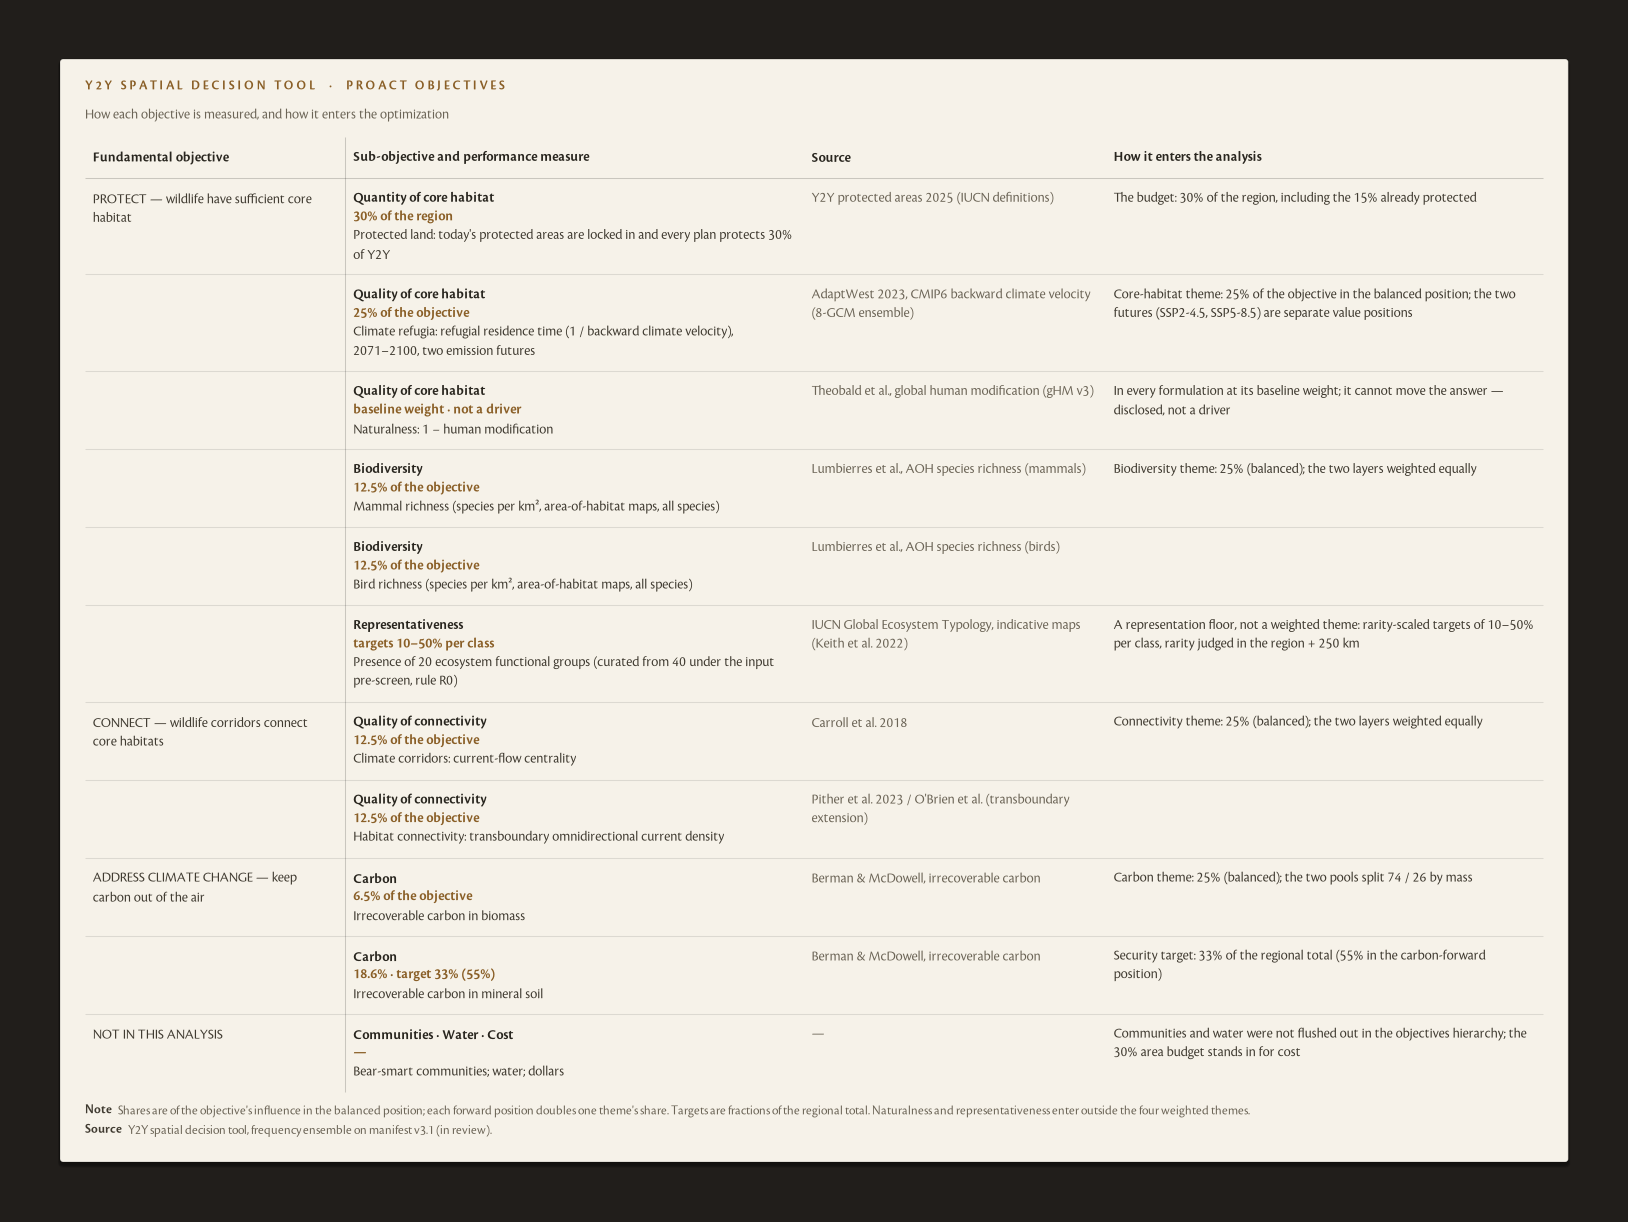

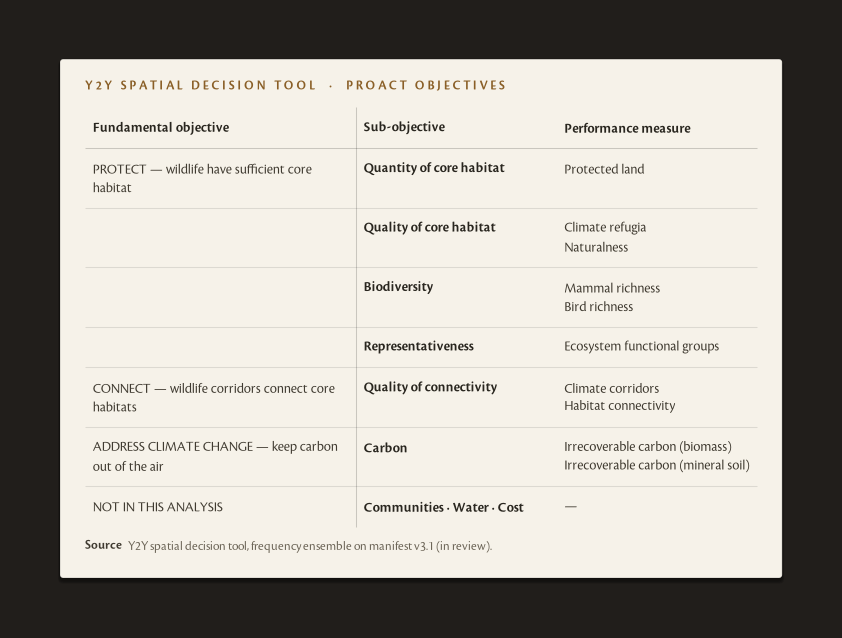

In [2]:
# ---- 1. the values in the analysis (Carbon-Poster rendering, dp.STYLE['values_table']; 'digest' / 'plain' are one switch away) -------------------------------------------------------------------------------
dp.values_table(C, OUT / "01_values_table.png")
dp.values_table_simple(C, OUT / "01b_values_table_simple.png")     # the bare-bones version for the slides


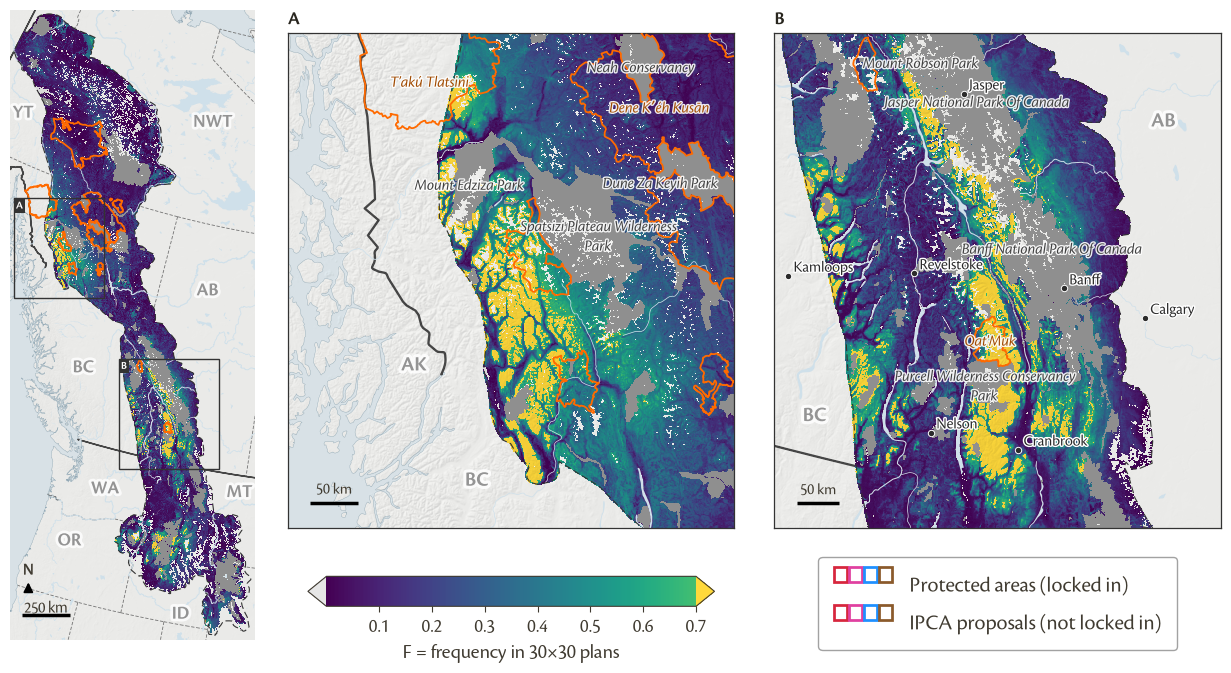

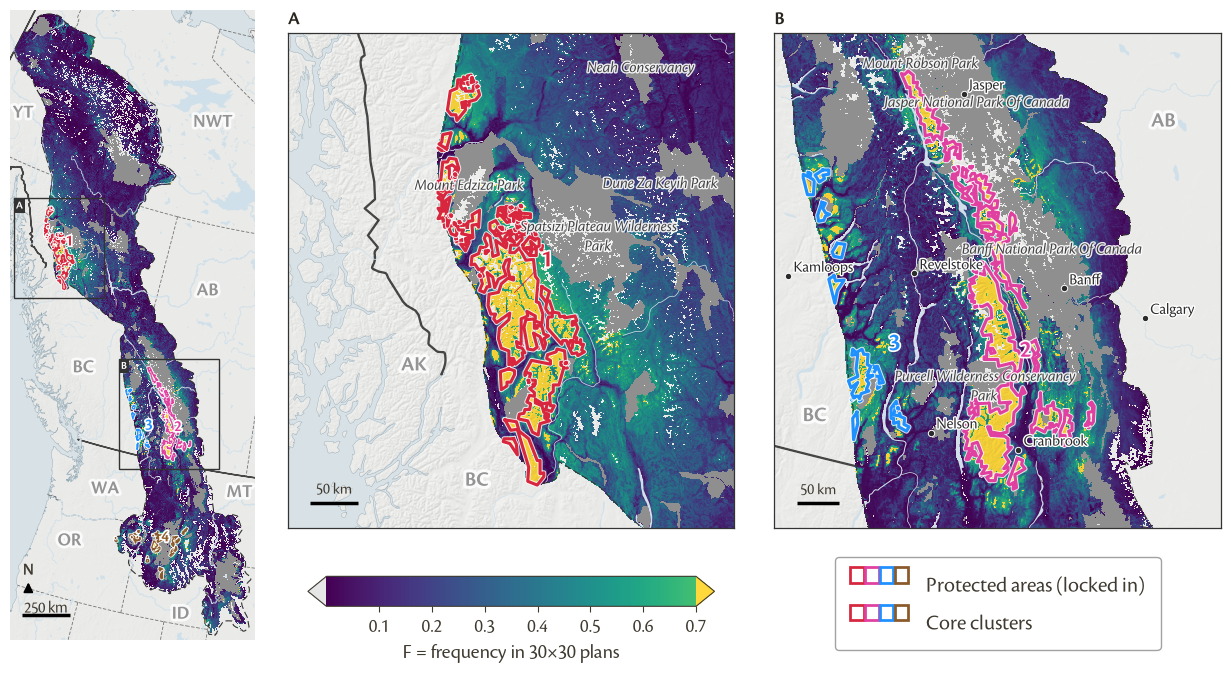

In [3]:
# ---- 2. Act 1 — the core at 1 km, two maps: (a) F over unprotected land with the IPCA proposals, (b) the four regional core clusters (numbered north -> south) ----
dp.core_map_F(C, OUT / "02a_act1_core_F.png")
dp.core_map_clusters(C, OUT / "02b_act1_core_clusters.png")


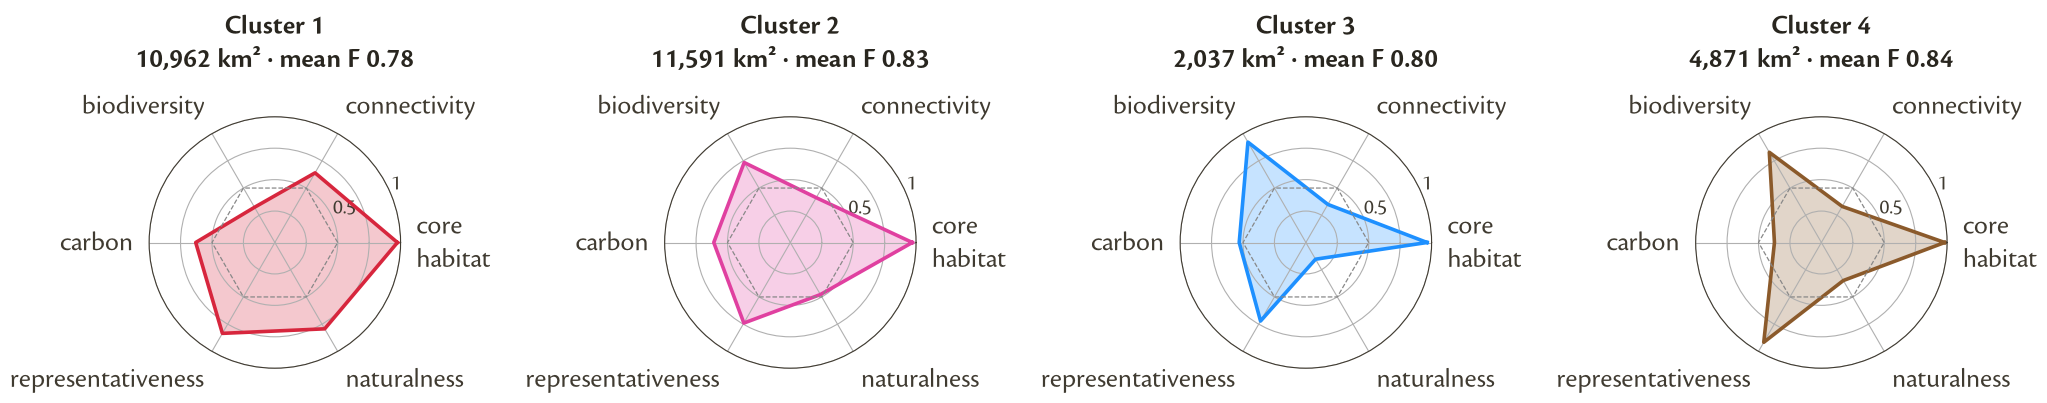

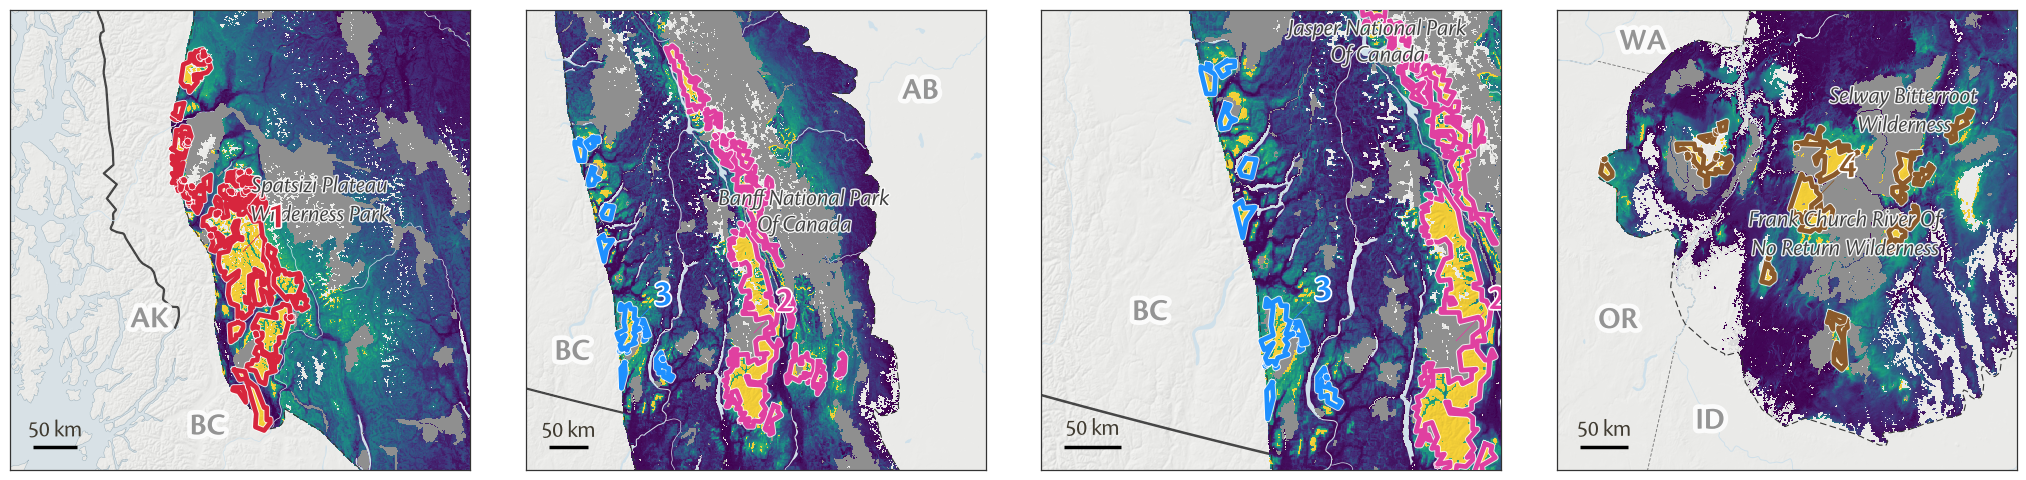

In [4]:
# ---- 3. Act 1 — star plots of the four core clusters -----------------------------------------------------------
dp.core_stars(C, OUT / "03_act1_core_stars.png")
dp.cluster_locators(C, OUT / "03b_act1_cluster_locators.png", panel_px=620)   # one window per cluster, aligned under the stars; + each panel as its own ~410 px file


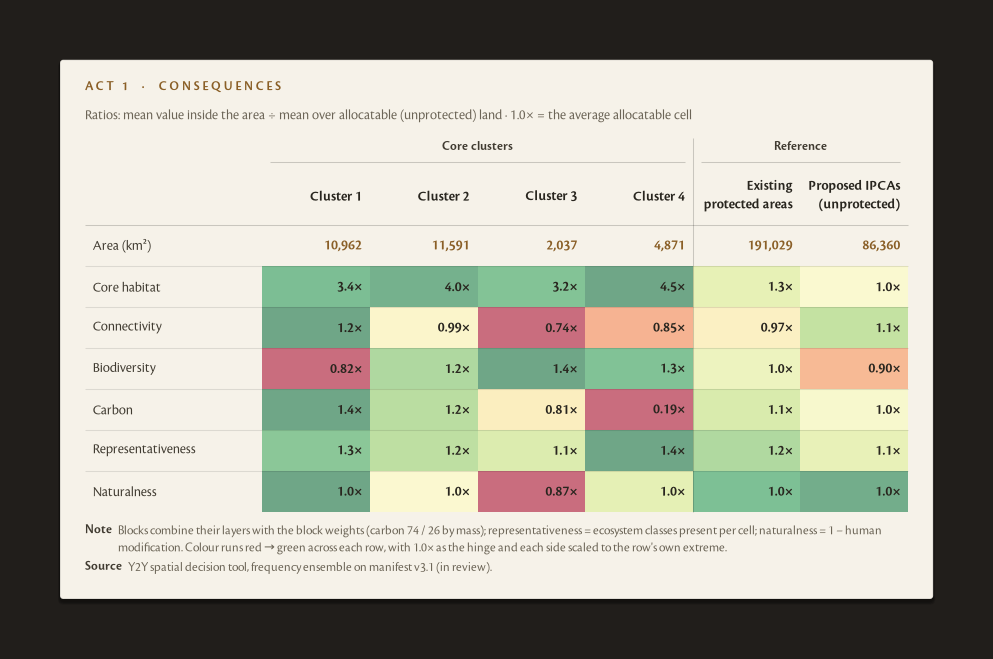

In [5]:
# ---- 4. Act 1 — consequences: mean value in the cluster / mean over allocatable land ("2.3x") -------------------
dp.core_consequences(C, OUT / "04_act1_consequences.png")


## Next outputs to add (say the word)
Act 2 pairings (value | tier) per scenario · Act 2 stars and consequences · the hinge cross-tab · the Act 3 gap map ·
the summary tiers map · the E17 one-pager.